In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Ensure reproducibility

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Data Exploration

In [3]:
df = pd.read_csv("bots_vs_users.csv")
X = df.drop("target", axis=1)
y = df["target"]

In [4]:
display(df)

,has_domain,has_birth_date,has_photo,can_post_on_wall,can_send_message,has_website,gender,has_short_name,has_first_name,has_last_name,...,ads_ratio,avg_views,posting_frequency_days,phone_numbers_ratio,avg_text_uniqueness,city,has_occupation,occupation_type_university,occupation_type_work,has_personal_data
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5869,1.0,1.0,1.0,0.0,0.0,Unknown,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Saint Petersburg,1.0,0.0,1.0,Unknown
5870,1.0,Unknown,1.0,0.0,0.0,Unknown,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Saint Petersburg,1.0,1.0,0.0,Unknown
5871,1.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Saint Petersburg,1.0,1.0,0.0,Unknown
5872,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Moscow,1.0,0.0,1.0,Unknown


In [5]:
# Missing values

nan_counts = df.isna().sum()
unknown_counts = (df == "Unknown").sum()

missing_summary = pd.DataFrame({
    'Data_types': df.dtypes,
    'NaN_count': nan_counts,
    'Unknown_count': unknown_counts
})
missing_summary['Total_missing'] = missing_summary['NaN_count'] + missing_summary['Unknown_count']
missing_summary = missing_summary.sort_values(by='Total_missing', ascending=False)

missing_summary

,Data_types,NaN_count,Unknown_count,Total_missing
has_personal_data,object,0,5006,5006
has_interests,object,0,4601,4601
has_relatives,object,0,4601,4601
has_schools,object,0,4601,4601
has_universities,object,0,4601,4601
marital_status,object,0,4601,4601
has_hometown,object,0,4601,4601
has_military_service,object,0,4601,4601
has_career,object,0,4601,4601
has_music,object,0,4601,4601


In [6]:
# Filter for categorical columns (object or category types)
categorical_cols = df.select_dtypes(include=['object', 'category'])

# Count unique values in each
category_counts = categorical_cols.nunique().sort_values(ascending=False)

# Display as a DataFrame
category_summary = pd.DataFrame({
    'Column': category_counts.index,
    'Unique_Categories': category_counts.values
})

category_summary


,Column,Unique_Categories
0,subscribers_count,1597
1,city,362
2,marital_status,9
3,gender,4
4,has_games,3
5,has_movies,3
6,has_activities,3
7,has_music,3
8,can_add_as_friend,3
9,can_invite_to_group,3


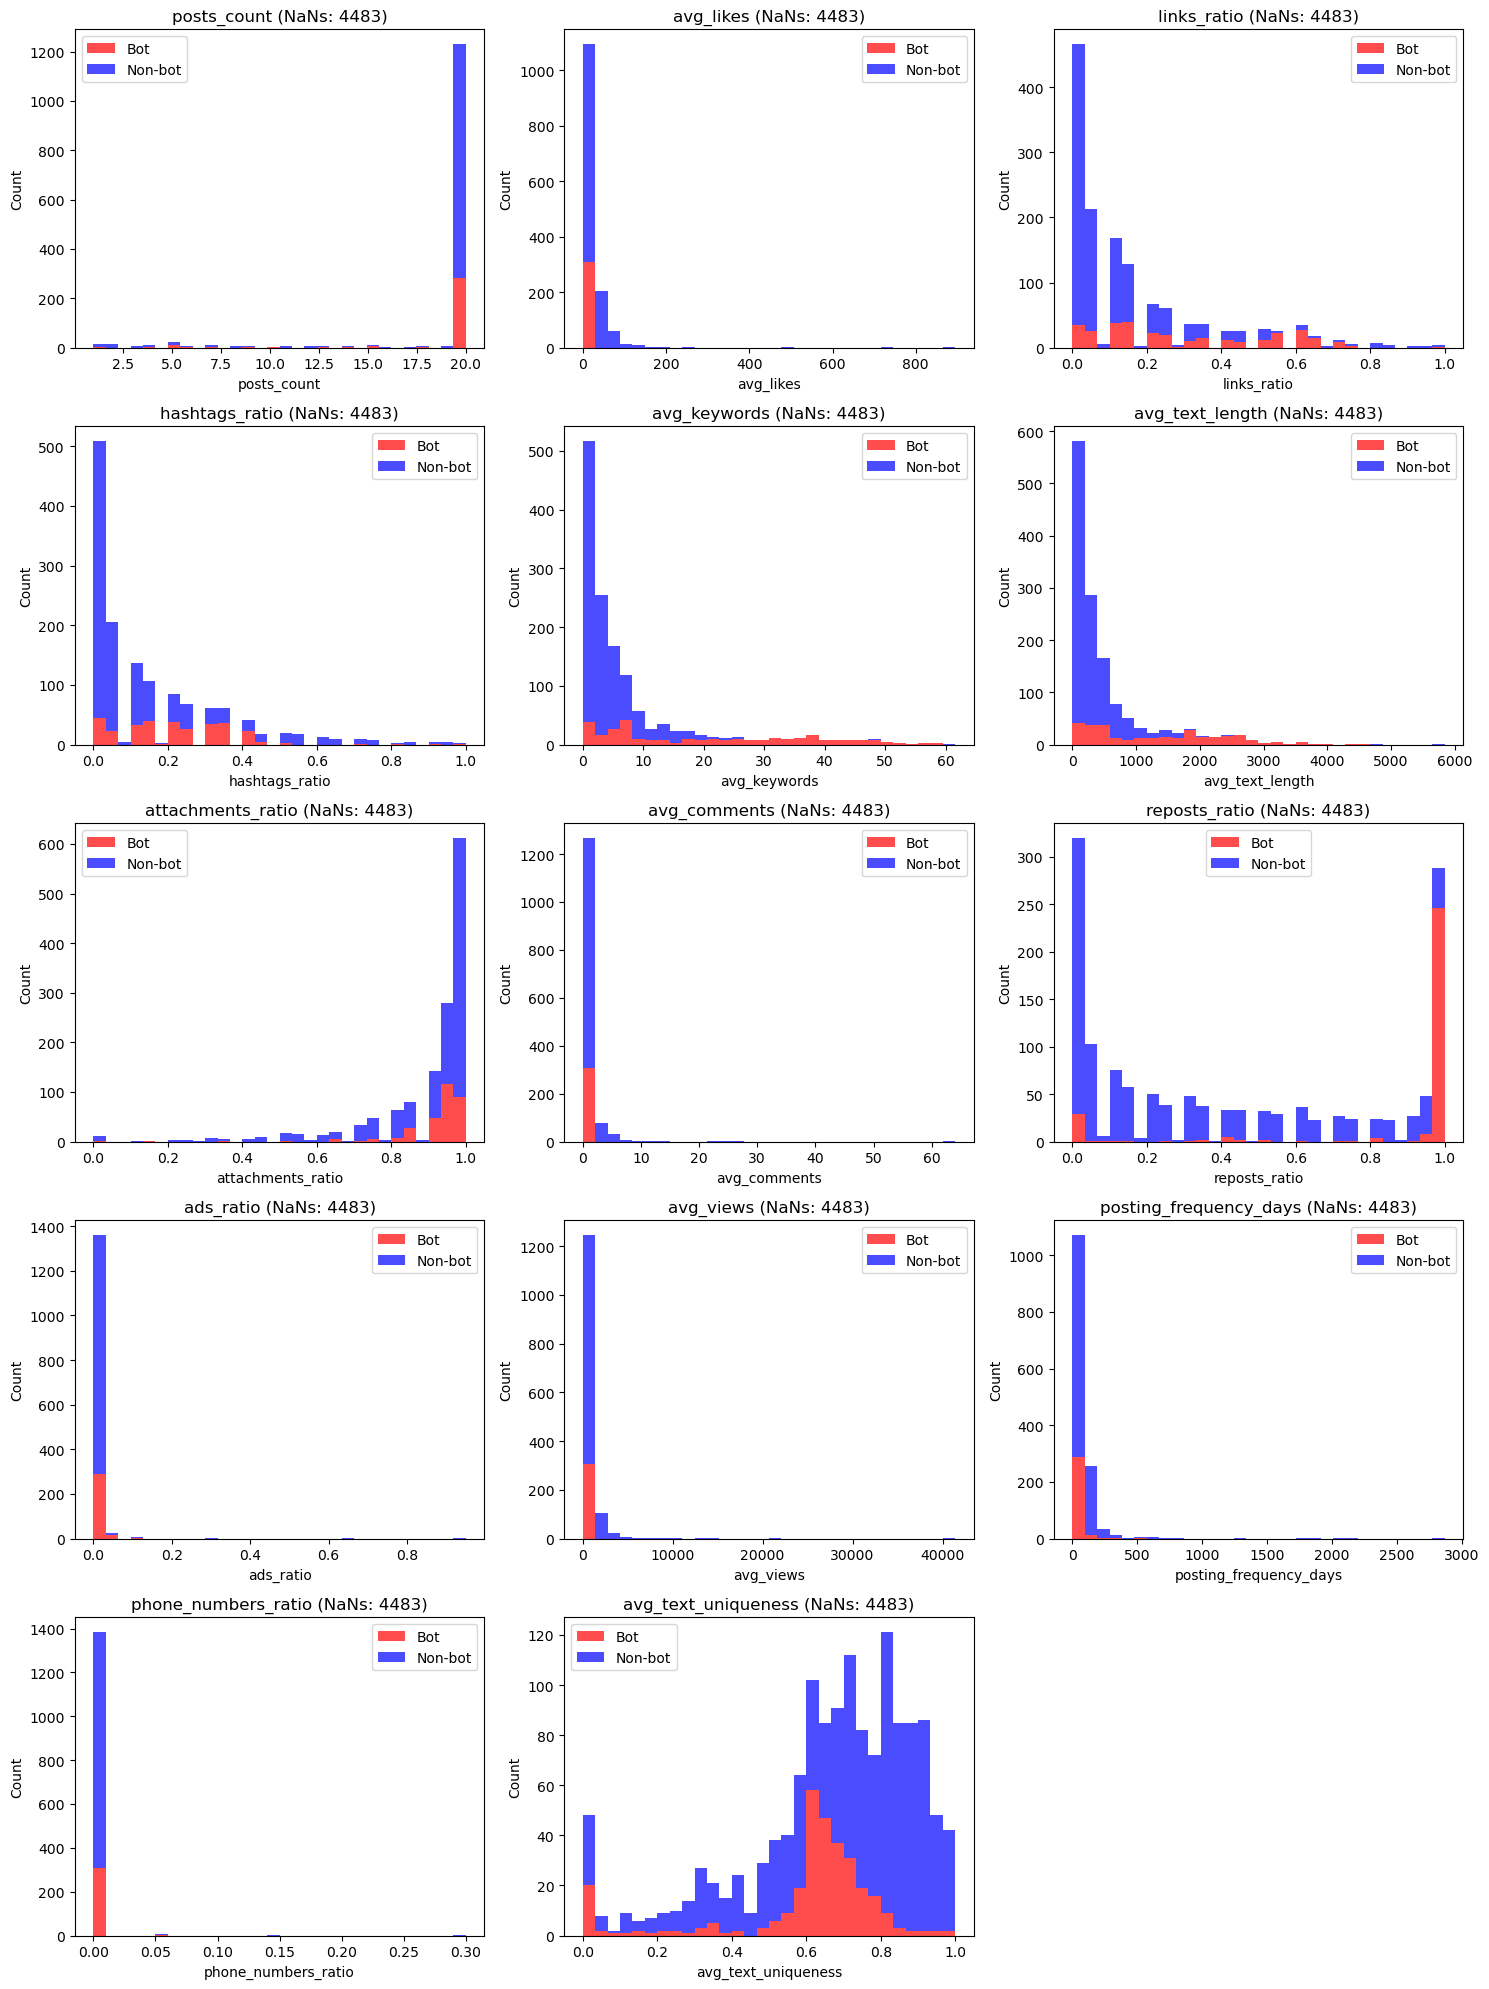

In [7]:
import matplotlib.pyplot as plt

def plot_continuous(X,y):
    # Select continuous variables with more than 10 unique values
    continuous_cols = [col for col in X.select_dtypes(include=['float', 'int']).columns 
                    if X[col].nunique() > 0]

    # Set up the plotting grid
    n_cols = 3
    n_rows = (len(continuous_cols) + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 5, n_rows * 4))

    # Plot stacked histograms per variable
    for i, col in enumerate(continuous_cols, 1):
        plt.subplot(n_rows, n_cols, i)

        # Drop NaNs just for the plot
        data = X[col].dropna()

        # Create two series: one for bots and one for non-bots
        bot_data = data[y == 1]
        non_bot_data = data[y == 0]

        # Plot stacked histogram
        plt.hist([bot_data, non_bot_data], bins=30, stacked=True, label=['Bot', 'Non-bot'], alpha=0.7, color=["r", "b"])
        plt.title(f"{col} (NaNs: {X[col].isna().sum()})")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_continuous(X,y)

In [8]:
# Check if all continuous values are missing for the same rows
continuous_cols = [col for col in df.select_dtypes(include=['float', 'int']).columns if col != 'target']
rows_all_continuous_nan = df[continuous_cols].isna().all(axis=1)
print(rows_all_continuous_nan.sum())

users_with_no_continuous_data = df[rows_all_continuous_nan]

4483


In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns

# Count 'Unknown' per row
unknown_counts = users_with_no_continuous_data[categorical_cols].apply(lambda row: (row == 'Unknown').sum(), axis=1)

# Add this to the DataFrame for inspection
users_with_no_continuous_data = users_with_no_continuous_data.copy()
users_with_no_continuous_data['num_unknown_categoricals'] = unknown_counts

In [10]:
users_with_data = df[~rows_all_continuous_nan]
unknown_counts_with_data = users_with_data[categorical_cols].apply(lambda row: (row == 'Unknown').sum(), axis=1)

print("Users with NO continuous data:")
print(users_with_no_continuous_data['num_unknown_categoricals'].describe())

print("\nUsers WITH continuous data:")
print(unknown_counts_with_data.describe())


Users with NO continuous data:
count    4483.000000
mean       25.453714
std         9.573049
min         0.000000
25%        19.000000
50%        32.000000
75%        33.000000
max        45.000000
Name: num_unknown_categoricals, dtype: float64

Users WITH continuous data:
count    1391.000000
mean        8.828181
std         8.453084
min         0.000000
25%         1.000000
50%         5.000000
75%        17.000000
max        45.000000
dtype: float64


In [11]:
print("Bot rate (target=1) among users with NO continuous data:")
print(users_with_no_continuous_data['target'].value_counts(normalize=True))

print("\nBot rate among users WITH continuous data:")
print(users_with_data['target'].value_counts(normalize=True))


Bot rate (target=1) among users with NO continuous data:
target
1    0.586438
0    0.413562
Name: proportion, dtype: float64

Bot rate among users WITH continuous data:
target
0    0.778577
1    0.221423
Name: proportion, dtype: float64


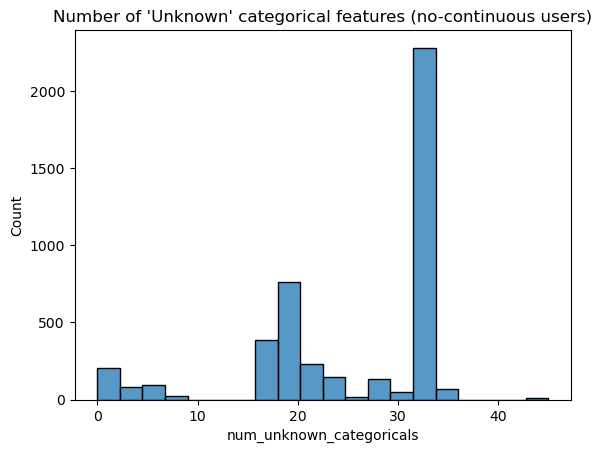

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(users_with_no_continuous_data['num_unknown_categoricals'], bins=20)
plt.title("Number of 'Unknown' categorical features (no-continuous users)")
plt.show()


In [13]:
# Count number of users per city
city_counts = df['city'].value_counts()

frequent_cities = city_counts[city_counts >= 30]

print(f"{len(frequent_cities)} cities have at least 30 users.")
print(frequent_cities)


5 cities have at least 30 users.
city
Unknown             2780
Saint Petersburg    1549
Kostomuksha          405
Moscow               335
Petrozavodsk         103
Name: count, dtype: int64


# Data preprocessing

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_subscriber_count_distribution(df, column='subscribers_count', bins=50):
    # Show value counts (excluding NaNs)
    print("Top subscriber counts (excluding NaN):")
    print(df[column].value_counts().sort_index().head(10))
    
    # Show number and proportion of NaNs
    nan_count = df[column].isna().sum()
    total = len(df)
    print(f"\nNaNs: {nan_count} ({nan_count / total:.2%} of total)")

    # Plot histogram of non-NaN values
    plt.figure(figsize=(8, 5))
    df[column].dropna().plot(kind='hist', bins=bins, edgecolor='black')
    plt.title(f"Distribution of {column} (excluding NaNs)")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# plot_subscriber_count_distribution(df)


In [16]:
# Check if subs has NaN and if yes, if it's at the same place as the othre continuous NaNs

In [17]:
# Train/test split
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=SEED)

In [18]:
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.impute import SimpleImputer

class DataCleaner:
    def __init__(self, scaler="standard", DT=False):
        self.scaler_collumns = None
        self.transform_map = {}
        self.DT = DT
        self.imputer = SimpleImputer(strategy='median')

        if scaler == "standard":
            self.scaler = StandardScaler()
        elif scaler == "robust":
            self.scaler = RobustScaler()
        elif scaler == "yeo-johnson":
            self.scaler = PowerTransformer(method='yeo-johnson', standardize=True)

    def transform(self, X): # For X_test (after fit_transform has been called)
        continuous_cols = X.select_dtypes(include=['float', 'int']).columns
        X_con = X[continuous_cols].copy()
        X_cat = X.drop(columns=continuous_cols).copy()
        X_cat = self.add_minimal_profile_flag(X_con, X_cat)
        X_con, X_cat = self.subs_to_continuous(X_con, X_cat)
        if not self.DT:
            X_con = pd.DataFrame(self.scaler.transform(X_con), columns=X_con.columns, index=X_con.index)
            X_con = pd.DataFrame(self.imputer.transform(X_con), columns=X_con.columns, index=X_con.index)
        for col in self.cat_transform:
            transformed = self.cat_transform[col](X_cat[col])
            X_cat = X_cat.drop(columns=[col])
            X_cat = pd.concat([X_cat, transformed], axis=1)
        return pd.concat([X_con, X_cat], axis=1)

    def fit_transform(self, X): # For X_train (learns features for transformation)
        continuous_cols = X.select_dtypes(include=['float', 'int']).columns
        X_con = X[continuous_cols].copy()
        X_cat = X.drop(columns=continuous_cols).copy()
        X_cat = self.add_minimal_profile_flag(X_con, X_cat)
        X_con, X_cat = self.subs_to_continuous(X_con, X_cat)
        if not self.DT:
            X_con = pd.DataFrame(self.scaler.fit_transform(X_con), columns=X_con.columns, index=X_con.index)
            X_con = pd.DataFrame(self.imputer.fit_transform(X_con), columns=X_con.columns, index=X_con.index)
        X_cat = self.one_hot_encode_thresholded(X_cat)
        return pd.concat([X_con, X_cat], axis=1)

    def add_minimal_profile_flag(self, X_con, X_cat): # Add feature identifying users without categorical features
        X_cat['is_minimal_profile'] = X_con.isna().all(axis=1).astype(int)
        return X_cat

    def subs_to_continuous(self, X_con, X_cat): # Turn subscriber count into continuous var
        # Clean the column: remove commas, spaces, and convert to numeric
        X_con['subscribers_count'] = pd.to_numeric(
            X_cat['subscribers_count']
            .replace("Unknown", np.nan)
            .astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
            .replace("", np.nan)  # Handle empty strings from non-numeric entries
        )

        # Drop the temp column
        X_cat.drop(columns='subscribers_count', inplace=True)
        
        return X_con, X_cat

    def one_hot_encode_thresholded(self, X_cat, min_count=30):
        """
        One-hot encodes all categorical columns with >2 unique values.
        - Rare categories (< min_count) in train set are grouped:
            - If only one rare category: its name is kept
            - If multiple: grouped into 'Other'
        - Binary columns (≤2 unique values) are left untouched
        - Columns with all categories above min_count get standard one-hot

        Returns:
            train_df, test_df

        Creates:
            self.cat_cols
        """
        self.cat_transform = {}

        for col in X_cat.columns:
            num_cats = X_cat[col].nunique(dropna=False)

            if num_cats == 2:
                
                def transform():
                    # During fitting (on train)
                    categories = X_cat[col].astype("category").cat.categories
                    mapping = {cat: i for i, cat in enumerate(categories)}
                    
                    def inner(series):
                        unknowns = ~series.isin(mapping)
                        if unknowns.any():
                            print(
                                f"Unknown categories found in column '{col}' during transform. "
                                "They will be mapped to index 0."
                            )
                        return series.map(mapping).fillna(0).astype(int)
                    
                    return inner

                transformer = transform()
                self.cat_transform[col] = transformer
                transformed = transformer(X_cat[col])
                X_cat = X_cat.drop(columns=[col])
                X_cat = pd.concat([X_cat, transformed], axis=1)

            if num_cats > 2:
                def transform():
                    value_counts = X_cat[col].value_counts()
                    frequent_cats = value_counts[value_counts >= min_count].index.tolist()
                    has_rare = len(value_counts[value_counts < min_count]) > 0
                    expected_cols = [f"{col}_{cat}" for cat in (["other"] if has_rare else []) + frequent_cats]
                    column_name = col

                    def inner(series):
                        series = series.where(series.isin(frequent_cats), "other")

                        dummies = pd.get_dummies(series, prefix=column_name).astype(int)

                        for missing in set(expected_cols) - set(dummies.columns):
                            print(f"Expected category '{missing}' not found in data — filling with 0s")
                            dummies[missing] = 0

                        return dummies[expected_cols]

                    return inner


                transformer = transform()
                self.cat_transform[col] = transformer
                transformed = transformer(X_cat[col])
                X_cat = X_cat.drop(columns=[col])
                X_cat = pd.concat([X_cat, transformed], axis=1)

        return X_cat


In [19]:
def test_cleaner():
    test = pd.read_csv("bots_vs_users.csv")
    test = test[["avg_text_length", "subscribers_count", "city", "has_photo", "has_domain"]]
    display(test) #.sort_values("subscribers_count", ascending=False))
    #plot_continuous(test, y)
    cleaner = DataCleaner("yeo-johnson", DT=False)
    transformed1 = cleaner.fit_transform(test)
    display(transformed1)
    transformed = cleaner.transform(test)
    display(transformed) #.sort_values("subscribers_count", ascending=False))
    plot_continuous(transformed, y)

def test_test():
    test = pd.read_csv("bots_vs_users.csv")
    test_short = test[["avg_text_length", "subscribers_count", "city", "has_photo", "has_domain"]]
    
    cleaner = DataCleaner("yeo-johnson")
    transformed_train = cleaner.fit_transform(test_short)
    transformed_test = cleaner.transform(test_short)  # or cleaner.transform() if you add that method

    print("=== DataFrame Comparison Report ===")

    if transformed_train.equals(transformed_test):
        print("✅ DataFrames are exactly equal.")
        return

    print("❌ DataFrames are NOT equal. Here's what's different:")

    if not transformed_train.columns.equals(transformed_test.columns):
        print("🟡 Columns differ:")
        print(" - In train but not in test:", set(transformed_train.columns) - set(transformed_test.columns))
        print(" - In test but not in train:", set(transformed_test.columns) - set(transformed_train.columns))

    if not transformed_train.index.equals(transformed_test.index):
        print("🟡 Index differs:")
        print(" - Train index:", transformed_train.index)
        print(" - Test index:", transformed_test.index)

    if not (transformed_train.dtypes == transformed_test.dtypes).all():
        print("🟡 Data types differ:")
        print(pd.concat([transformed_train.dtypes, transformed_test.dtypes], axis=1, keys=['Train', 'Test']))

    unequal_mask = ~(transformed_train == transformed_test)
    if unequal_mask.any().any():
        print("🟥 Data values differ at these locations:")
        diffs = unequal_mask.stack()[lambda x: x]
        for index in diffs.index:
            i, col = index
            print(f" - Row {i}, Column '{col}': Train = {transformed_train.at[i, col]}, Test = {transformed_test.at[i, col]}")

    print("===================================")

test_test()

=== DataFrame Comparison Report ===
✅ DataFrames are exactly equal.


In [20]:
cleaner_NN = DataCleaner("yeo-johnson", DT=False)
X_train_NN = cleaner_NN.fit_transform(X_train)
X_test_NN = cleaner_NN.transform(X_test)

cleaner_DT = DataCleaner(DT=True)
X_train_DT = cleaner_DT.fit_transform(X_train)
X_test_DT = cleaner_DT.transform(X_test)


# display(X_train_NN)
# display(X_train_DT) #.sort_values("subscribers_count", ascending=False))
# plot_continuous(X_train_DT, y)

Expected category 'is_confirmed_other' not found in data — filling with 0s
Expected category 'is_confirmed_other' not found in data — filling with 0s


# Determine Baseline Performance

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy = DummyClassifier(strategy="most_frequent")  # or "stratified", "uniform"
dummy.fit(X_train_NN, y_train)
print(classification_report(y_test, dummy.predict(X_test_NN), zero_division=0))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       735
           1       0.50      1.00      0.67       734

    accuracy                           0.50      1469
   macro avg       0.25      0.50      0.33      1469
weighted avg       0.25      0.50      0.33      1469



In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold


# Create a results list
results = []

# Run 10 separate studies with different sampler seeds
for i in range(10):
    sampler_seed = SEED + i
    sampler = optuna.samplers.TPESampler(seed=sampler_seed)
    study = optuna.create_study(direction='maximize', sampler=sampler)

    def objective(trial):
        param = {
            'C': trial.suggest_float('C', 0.01, 100, log=True),
        }
        model = LogisticRegression(**param, random_state=SEED, max_iter=1000)

        # Vary the CV seed using trial number and outer loop seed
        cv_seed = SEED + trial.number + i * 1000
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=cv_seed)
        score = cross_val_score(model, X_train_NN, y_train, cv=cv, scoring='f1').mean()
        return score

    study.optimize(objective, n_trials=30)

    # Collect results
    results.append({
        'run': i,
        'best_C': study.best_params['C'],
        'best_f1': study.best_value
    })

# Create a DataFrame for analysis
results_df = pd.DataFrame(results)
print(results_df)

# Optional: analyze variability
print("\nC value variability:")
print(results_df['best_C'].describe(), "Median:", results_df["best_C"].median())
print("\nF1 score variability:")
print(results_df['best_f1'].describe())


[I 2025-05-10 14:32:27,171] A new study created in memory with name: no-name-ac64d143-9877-461d-a4fe-cbe2c4fbc9ad
[I 2025-05-10 14:32:27,511] Trial 0 finished with value: 0.9717120639285536 and parameters: {'C': 0.3148911647956863}. Best is trial 0 with value: 0.9717120639285536.
[I 2025-05-10 14:32:27,860] Trial 1 finished with value: 0.9743092308073642 and parameters: {'C': 63.51221010640699}. Best is trial 1 with value: 0.9743092308073642.
[I 2025-05-10 14:32:28,173] Trial 2 finished with value: 0.9739549085224608 and parameters: {'C': 8.471801418819982}. Best is trial 1 with value: 0.9743092308073642.
[I 2025-05-10 14:32:28,468] Trial 3 finished with value: 0.9733043401161077 and parameters: {'C': 2.481040974867812}. Best is trial 1 with value: 0.9743092308073642.
[I 2025-05-10 14:32:28,672] Trial 4 finished with value: 0.9688881870232302 and parameters: {'C': 0.04207988669606637}. Best is trial 1 with value: 0.9743092308073642.
[I 2025-05-10 14:32:28,867] Trial 5 finished with val

   run    best_C   best_f1
0    0  2.326669  0.975266
1    1  1.460995  0.975459
2    2  3.884493  0.975694
3    3  2.426869  0.975427
4    4  1.944046  0.975257
5    5  9.772313  0.975700
6    6  2.272066  0.975016
7    7  3.945181  0.975714
8    8  2.697272  0.975011
9    9  1.733918  0.975059

C value variability:
count    10.000000
mean      3.246382
std       2.436363
min       1.460995
25%       2.026051
50%       2.376769
75%       3.587688
max       9.772313
Name: best_C, dtype: float64

F1 score variability:
count    10.000000
mean      0.975360
std       0.000282
min       0.975011
25%       0.975109
50%       0.975346
75%       0.975635
max       0.975714
Name: best_f1, dtype: float64


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1 # use all available cores
)

grid_search.fit(X_train_NN, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_NN)

print("Best Hyperparameters:", grid_search.best_params_)


Best Hyperparameters: {'C': 1}


In [25]:
param_grid = {
    'C': [0.5, 0.75, 1, 2.5, 5],
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1 # use all available cores
)

grid_search.fit(X_train_NN, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_NN)

print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'C': 2.5}


In [26]:
param_grid = {
    'C': [1.5, 2, 2.5, 3, 3.5],
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1, # use all available cores
)

grid_search.fit(X_train_NN, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_NN)

print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'C': 2.5}


In [27]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[724  11]
 [ 28 706]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       735
           1       0.98      0.96      0.97       734

    accuracy                           0.97      1469
   macro avg       0.97      0.97      0.97      1469
weighted avg       0.97      0.97      0.97      1469



In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_NN, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_NN)

print("Best Hyperparameters:", grid_search.best_params_)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
[[715  20]
 [ 29 705]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       735
           1       0.97      0.96      0.97       734

    accuracy                           0.97      1469
   macro avg       0.97      0.97      0.97      1469
weighted avg       0.97      0.97      0.97      1469



# Train Models

## XGBoost

In [29]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 1.0],
    'gamma': [0, 1, 5],
    'lambda': [0, 1, 10],
    'alpha': [0, 1, 10],
    'scale_pos_weight': [1, 10]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

# grid_search.fit(X_train_NN, y_train)

# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test_NN)

# print("Best Hyperparameters:", grid_search.best_params_)
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))


In [ ]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        #'lambda': trial.suggest_float('lambda', 0, 10),
        #'alpha': trial.suggest_float('alpha', 0, 10),
        #'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 10]),
    }
    model = xgb.XGBClassifier(**param, eval_metric='logloss')

    # Ensure reproducibility while maintaining variation
    cv_seed = SEED + trial.number
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=cv_seed)
    score = cross_val_score(model, X_train_NN, y_train, cv=cv, scoring='f1').mean()
    return score

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=10)

print("Best parameters:", study.best_params)
print("Best f1:", study.best_value)

In [48]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold

results = []

for i in range(5):
    sampler_seed = SEED + i
    sampler = optuna.samplers.TPESampler(seed=sampler_seed)
    study = optuna.create_study(direction='maximize', sampler=sampler)

    def objective(trial):
        param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        #'lambda': trial.suggest_float('lambda', 0, 10),
        #'alpha': trial.suggest_float('alpha', 0, 10),
        #'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 10]),
        }   
        model = xgb.XGBClassifier(**param, eval_metric='logloss', random_state=SEED)

        # Vary the CV seed using trial number and outer loop seed
        cv_seed = SEED + trial.number + i * 1000
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=cv_seed)
        score = cross_val_score(model, X_train_NN, y_train, cv=cv, scoring='f1').mean()
        return score

    study.optimize(objective, n_trials=50)

    # Collect results
    results.append({
        'run': i,
        **study.best_params,
        'best_study': study,
        'best_f1': study.best_value,
    })

# Create a DataFrame for analysis
results_df = pd.DataFrame(results)
display(results_df)

summary_df = results_df.drop(columns=['run', 'best_study']).agg(['mean', 'std', 'median']).T
summary_df = summary_df[['mean', 'std', 'median']]  # reorder if needed
summary_df = summary_df.round(4)
display(summary_df)

[I 2025-05-10 15:10:11,938] A new study created in memory with name: no-name-27b4bce3-5ce6-4826-aed0-34c38f6e22fb
[I 2025-05-10 15:10:13,878] Trial 0 finished with value: 0.9746072604786592 and parameters: {'n_estimators': 218, 'learning_rate': 0.28570714885887566, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 0.9746072604786592.
[I 2025-05-10 15:10:15,536] Trial 1 finished with value: 0.9767975627195948 and parameters: {'n_estimators': 440, 'learning_rate': 0.18432335340553055, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 1.0616955533913808}. Best is trial 1 with value: 0.9767975627195948.
[I 2025-05-10 15:10:16,483] Trial 2 finished with value: 0.9761799716253439 and parameters: {'n_estimators': 132, 'learning_rate': 0.06318730785749581, 'max_depth': 4, 'min_child_weight': 3, 'subsample':

,run,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,best_study,best_f1
0,0,465,0.182780,4,3,0.775601,0.689511,1.598889,<optuna.study.study.Study object at 0x32caaca50>,0.977802
1,1,386,0.106555,7,1,0.823277,0.867581,1.877764,<optuna.study.study.Study object at 0x16a13dd10>,0.979066
2,2,469,0.094282,5,1,0.659368,0.666046,1.974219,<optuna.study.study.Study object at 0x32e885110>,0.978628
3,3,327,0.042498,3,1,0.776984,0.940998,2.094578,<optuna.study.study.Study object at 0x32caf1790>,0.978672
4,4,124,0.130366,8,1,0.721967,0.742261,1.352465,<optuna.study.study.Study object at 0x32e85b790>,0.978670


,mean,std,median
n_estimators,354.2000,141.5970,386.0000
learning_rate,0.1113,0.0513,0.1066
max_depth,5.4000,2.0736,5.0000
min_child_weight,1.4000,0.8944,1.0000
subsample,0.7514,0.0627,0.7756
colsample_bytree,0.7813,0.1185,0.7423
gamma,1.7796,0.3008,1.8778
best_f1,0.9786,0.0005,0.9787


In [49]:
for study in results_df["best_study"]:
    fig = optuna.visualization.plot_param_importances(study)
    fig.show()

In [55]:
model = xgb.XGBClassifier(n_estimators=100)
score = cross_val_score(model, X_train_NN, y_train, cv=5, scoring='f1').mean()
print(score)

0.9759496847113592


In [32]:
# Compare behavior on dataset with median imputation (for NaN) and dataset without median imputation

## NeuralNetwork

In [33]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Build the model
model = Sequential([
    Input(shape=(X_train_NN.shape[1],)),  # Explicit Input layer
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Output for binary classification
])


# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train_NN, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Predict and evaluate
y_pred_prob = model.predict(X_test_NN)
y_pred = (y_pred_prob > 0.5).astype("int32")

print(classification_report(y_test, y_pred))


Epoch 1/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8833 - loss: 0.3318 - val_accuracy: 0.9694 - val_loss: 0.0969
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9538 - loss: 0.1328 - val_accuracy: 0.9716 - val_loss: 0.0797
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9680 - loss: 0.1072 - val_accuracy: 0.9796 - val_loss: 0.0690
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9678 - loss: 0.1074 - val_accuracy: 0.9773 - val_loss: 0.0725
Epoch 5/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9688 - loss: 0.1075 - val_accuracy: 0.9807 - val_loss: 0.0684
Epoch 6/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9759 - loss: 0.0942 - val_accuracy: 0.9796 - val_loss: 0.0633
Epoch 7/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9756 - loss: 0.0785 - val_accuracy: 0.9796 - val_loss: 0.0631
Epoch 8/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9740 - loss: 0.0889 - val_accuracy: 0.